## Laboratorium 11

slajd 112 wyswietlic - ile razy algorytm sie pomylił i wybrał złego dostawcę

zadania ze slajdu 104

w 3 punkcie zmiana u dostawców (np jeden przestaje być najlepszym)

In [239]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import random

random.seed(42)

1. Reproduce example from the lecture (electronic system production)

In [240]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1

    def __init__(self, quality):
        self.quality = quality

    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)

    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good


class Factory:
    batches = []
    systems = 0
    good = 0

    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0

    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        choice = np.argmax(samples)
        result = self.batches[choice].get_element()
        self.systems = self.systems + 1
        self.good = self.good + int(result)

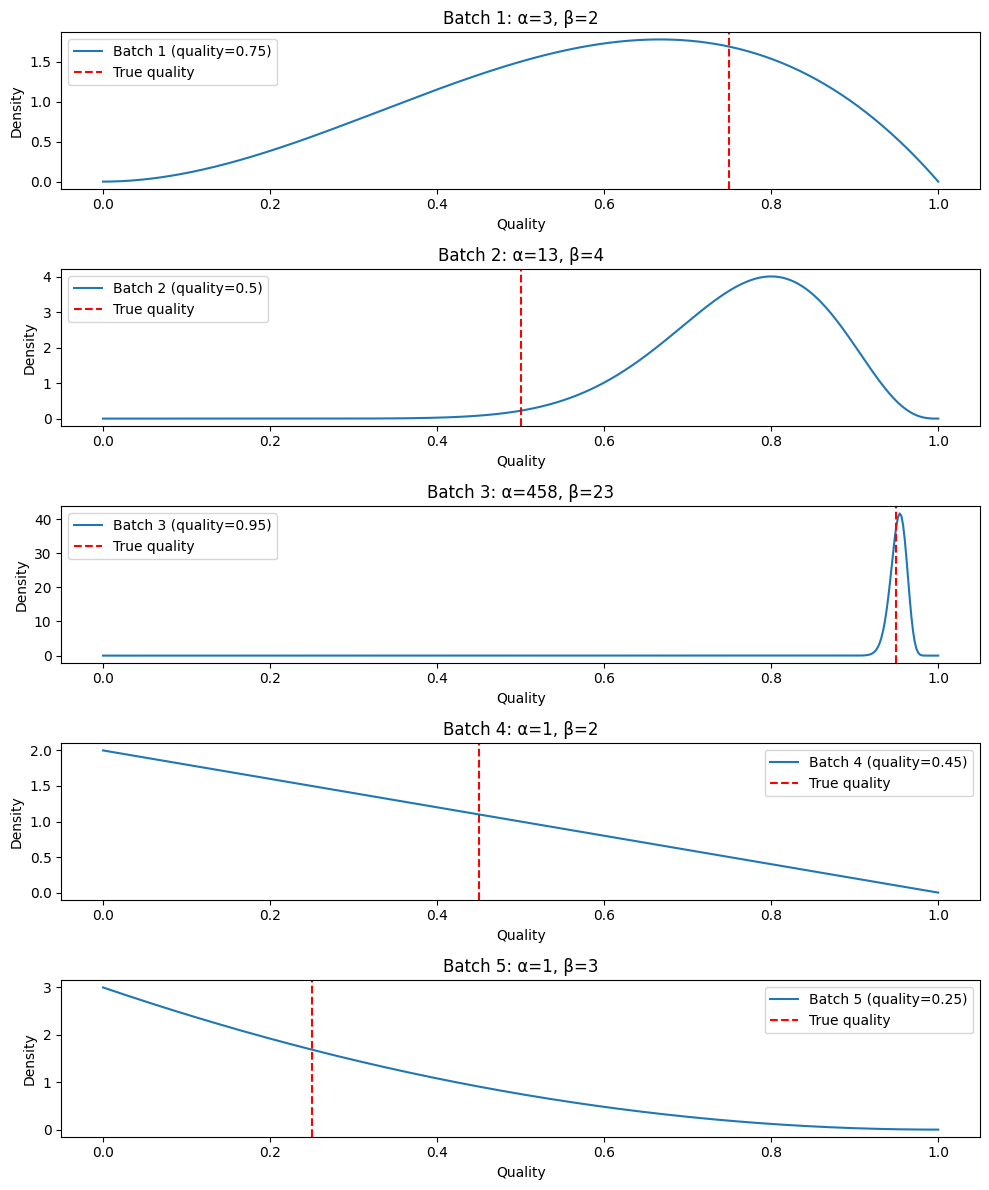

In [241]:
BATCHES_NUM = 5
qualities = [0.75, 0.5, 0.95, 0.45, 0.25]

STEPS = 500

factory = Factory()
factory.set_batches(qualities)
res = {}

for step in range(STEPS):
    factory.get_element()
    res[step] = [(b.alpha, b.beta, b.quality) for b in factory.batches]

x = np.linspace(0,1,STEPS)
fig, axes = plt.subplots(BATCHES_NUM, 1, figsize=(10, 12))

for i in range(BATCHES_NUM):
    alpha_final, beta_final, quality = res[STEPS-1][i]
    y = beta.pdf(x, alpha_final, beta_final)
    axes[i].plot(x, y, label=f'Batch {i+1} (quality={quality})')
    axes[i].axvline(quality, color='r', linestyle='--', label='True quality')
    axes[i].set_title(f'Batch {i+1}: α={alpha_final}, β={beta_final}')
    axes[i].legend()
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

2. Implement last three strategies from slide 105 plus one of your own (other than the two 
remaining in the slide), compare results in a plot.

In [242]:
class Batch:
    quality = 0.5
    alpha = 1
    beta = 1
    def __init__(self, quality):
        self.quality = quality
    
    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)
    
    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good
    
class Factory:
    batches = []
    systems = 0
    good = 0

    def reset(self):
        self.systems = 0          
        self.good = 0
    
    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.n_batches = len(qualities)
        self.systems = 0
        self.good = 0
    
    def lemon_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        last_batch_idx = 0
        for step in range(steps):
            choice = last_batch_idx
            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            
            self.systems = self.systems + 1
            self.good = self.good + int(result)
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")
            if result == False:
                last_batch_idx = last_batch_idx + 1 if last_batch_idx + 1 < self.n_batches else 0
            results.append(result)
            
        return results.count(True), batch_success, batch_total
    
    def rank_descending_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            successes = np.array([b.alpha - 1 for b in self.batches])
            failures = np.array([b.beta  - 1 for b in self.batches])
            total = successes + failures
            # print(f"{successes}, {failures}, {total}")

            mean_success = np.where(total > 0, successes / total, 0.5)

            order = np.argsort(-mean_success)
            choose_list = []
            for i, idx in enumerate(order):
                choose_list += [idx] * (self.n_batches - i)

            # print(choose_list)
            choice = choose_list[step % len(choose_list)]

            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")

            self.systems = self.systems + 1
            self.good = self.good + int(result)
            
            results.append(result)
        
        # return sum(batch_success) / sum(batch_used)
        return results.count(True), batch_success, batch_total
    
    def ratio_geometric_method(self, steps):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            successes = np.array([b.alpha - 1 for b in self.batches])
            failures = np.array([b.beta  - 1 for b in self.batches])
            total = successes + failures
            # print(f"{successes}, {failures}, {total}")

            mean_success = np.where(total > 0, successes / total, 0.5)
            order = np.argsort(mean_success)

            sorted_success = mean_success[order]
            ratios = np.zeros(len(order))
            ratios[0] = 1.0                       
            for i in range(1, len(order)):
                if sorted_success[i-1] == 0:
                    ratios[i] = 2.0
                else:
                    ratios[i] = sorted_success[i] / sorted_success[i-1]

            choose_list = []
            base_amount = 1.0
            for i, batch_idx in enumerate(order):
                amount = max(1, round(base_amount))
                choose_list += [batch_idx] * amount
                base_amount *= ratios[i]

            position = self.systems % len(choose_list)
            choice = choose_list[position]

            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")

            self.systems = self.systems + 1
            self.good = self.good + int(result)
            results.append(result)
        
        return results.count(True), batch_success, batch_total
    
    def softmax_method(self, steps, temp=4.0):
        results = []
        batch_success = np.zeros(self.n_batches)
        batch_total = np.zeros(self.n_batches)

        for step in range(steps):
            successes = np.array([b.alpha - 1 for b in self.batches])
            failures = np.array([b.beta  - 1 for b in self.batches])
            total = successes + failures
            # print(f"{successes}, {failures}, {total}")

            mean_success = np.where(total > 0, successes / total, 0.5)
            
            logits = mean_success / temp
            logits -= np.max(logits)
            exp_logits = np.exp(logits)
            probs = exp_logits / np.sum(exp_logits)

            choice = np.random.choice(self.n_batches, p=probs)
            
            result = self.batches[choice].get_element()
            batch_success[choice] += int(result)
            batch_total[choice] += 1
            # print(f"Batch chosen: {choice} -> res: {result}")
            # print(f"Batch: {self.batches[choice].alpha} | {self.batches[choice].beta}\n")

            self.systems = self.systems + 1
            self.good = self.good + int(result)
            results.append(result)
    
        return results.count(True), batch_success, batch_total
            


In [243]:
# BATCHES_NUM = 5
qualities = [0.65, 0.70, 0.75, 0.8, 0.85]
# qualities = [0.9, 0.6, 0.5, 0.4, 0.3]

STEPS = 100
SIM_NUMS = 1

scores = []

Lemon method:

In [244]:
lemon_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.lemon_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset()
    lemon_scores.append(results / STEPS)
    
    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(lemon_scores))
print(f"Avg. success rate: {sum(lemon_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 1 | Beta: 6
Batch 1: Alpha: 7 | Beta: 6
Batch 2: Alpha: 28 | Beta: 6
Batch 3: Alpha: 30 | Beta: 6
Batch 4: Alpha: 15 | Beta: 5
Success rate: 0.76
[ 0.  6. 27. 29. 14.]
[ 5. 11. 32. 34. 18.]
Avg. success rate: 0.76
Successful batch use:
Batch 0 (qual: 0.65): 0.0/5.0
Batch 1 (qual: 0.7): 6.0/11.0
Batch 2 (qual: 0.75): 27.0/32.0
Batch 3 (qual: 0.8): 29.0/34.0
Batch 4 (qual: 0.85): 14.0/18.0


Ranking descending method:

In [245]:
rank_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.rank_descending_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    rank_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(rank_scores))
print(f"Avg. success rate: {sum(rank_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}: {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 4 | Beta: 6
Batch 1: Alpha: 15 | Beta: 6
Batch 2: Alpha: 25 | Beta: 8
Batch 3: Alpha: 11 | Beta: 5
Batch 4: Alpha: 25 | Beta: 5
Success rate: 0.75
[ 3. 14. 24. 10. 24.]
[ 8. 19. 31. 14. 28.]
Avg. success rate: 0.75
Successful batch use:
Batch 0 (qual: 0.65: 3.0/8.0
Batch 1 (qual: 0.7: 14.0/19.0
Batch 2 (qual: 0.75: 24.0/31.0
Batch 3 (qual: 0.8: 10.0/14.0
Batch 4 (qual: 0.85: 24.0/28.0


C:\Users\jasin\AppData\Local\Temp\ipykernel_22052\2245016649.py:65: RuntimeWarning: invalid value encountered in divide
  mean_success = np.where(total > 0, successes / total, 0.5)


Ratio score method:

In [246]:
ratio_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.ratio_geometric_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    ratio_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)
        
scores.append(np.average(ratio_scores))
print(f"Avg. success rate: {sum(ratio_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")


Batch 0: Alpha: 7 | Beta: 10
Batch 1: Alpha: 13 | Beta: 7
Batch 2: Alpha: 11 | Beta: 4
Batch 3: Alpha: 32 | Beta: 7
Batch 4: Alpha: 15 | Beta: 4
Success rate: 0.73
[ 6. 12. 10. 31. 14.]
[15. 18. 13. 37. 17.]
Avg. success rate: 0.73
Successful batch use:
Batch 0 (qual: 0.65): 6.0/15.0
Batch 1 (qual: 0.7): 12.0/18.0
Batch 2 (qual: 0.75): 10.0/13.0
Batch 3 (qual: 0.8): 31.0/37.0
Batch 4 (qual: 0.85): 14.0/17.0


C:\Users\jasin\AppData\Local\Temp\ipykernel_22052\2245016649.py:100: RuntimeWarning: invalid value encountered in divide
  mean_success = np.where(total > 0, successes / total, 0.5)


Own method - softmax:

In [247]:
softmax_scores = []
for _ in range(SIM_NUMS):
    factory = Factory()
    factory.set_batches(qualities)
    results, batch_success, batch_total = factory.softmax_method(STEPS)
    for i, b in enumerate(factory.batches):
        print(f"Batch {i}: Alpha: {b.alpha} | Beta: {b.beta}")
    factory.reset() 
    softmax_scores.append(results / STEPS)

    if _ < 1:
        print(f"Success rate: {results / STEPS}")
        print(batch_success)
        print(batch_total)

scores.append(np.average(softmax_scores))
print(f"Avg. success rate: {sum(softmax_scores) / SIM_NUMS}")
print("Successful batch use:")
for i in range(len(qualities)):
    print(f"Batch {i} (qual: {qualities[i]}): {batch_success[i]}/{batch_total[i]}")

Batch 0: Alpha: 19 | Beta: 6
Batch 1: Alpha: 14 | Beta: 6
Batch 2: Alpha: 17 | Beta: 4
Batch 3: Alpha: 17 | Beta: 4
Batch 4: Alpha: 21 | Beta: 2
Success rate: 0.83
[18. 13. 16. 16. 20.]
[23. 18. 19. 19. 21.]
Avg. success rate: 0.83
Successful batch use:
Batch 0 (qual: 0.65): 18.0/23.0
Batch 1 (qual: 0.7): 13.0/18.0
Batch 2 (qual: 0.75): 16.0/19.0
Batch 3 (qual: 0.8): 16.0/19.0
Batch 4 (qual: 0.85): 20.0/21.0


C:\Users\jasin\AppData\Local\Temp\ipykernel_22052\2245016649.py:145: RuntimeWarning: invalid value encountered in divide
  mean_success = np.where(total > 0, successes / total, 0.5)


[np.float64(0.76), np.float64(0.75), np.float64(0.73), np.float64(0.83)]


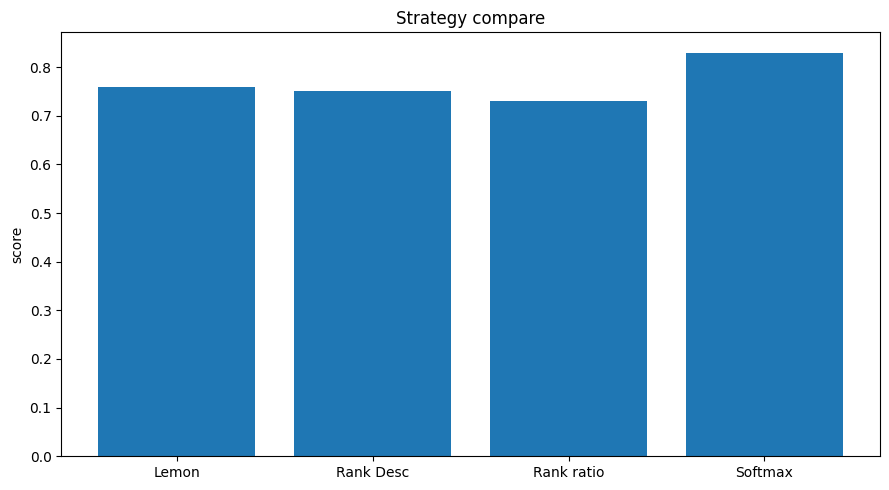

In [248]:
names = ["Lemon", "Rank Desc", "Rank ratio", "Softmax"]
print(scores)
plt.figure(figsize=(9,5))
plt.bar(names, scores)
plt.ylabel("score")
plt.title("Strategy compare")
plt.tight_layout()
plt.show()